# House price prediction

Predicting house `price` from the Housing dataset. Quick EDA, light cleaning, a few features, then three models.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from lightgbm import LGBMRegressor

sns.set_style('whitegrid')

In [ ]:
df = pd.read_csv('Housing.csv')
print(df.shape)
df.info()
df.describe()

(545, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## EDA



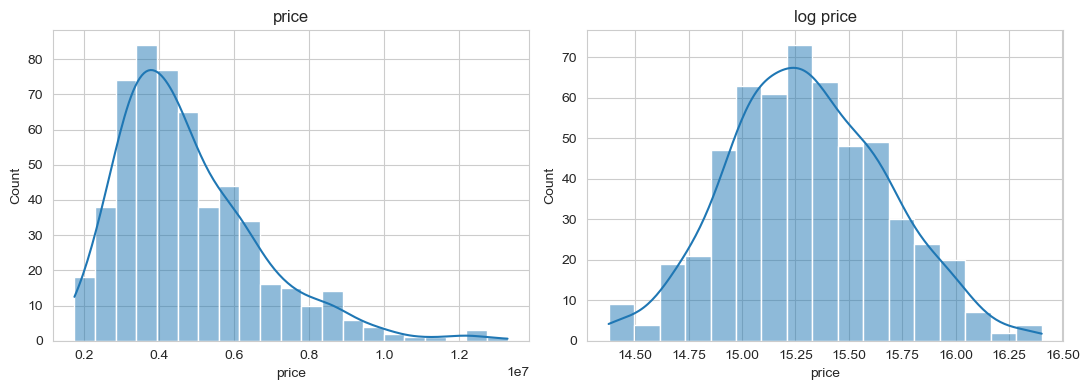

In [ ]:
# price is right skewed, long tail of expensive houses
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df['price'], kde=True, ax=ax[0])
ax[0].set_title('price')
sns.histplot(np.log(df['price']), kde=True, ax=ax[1])
ax[1].set_title('log price')
plt.tight_layout()
plt.show()

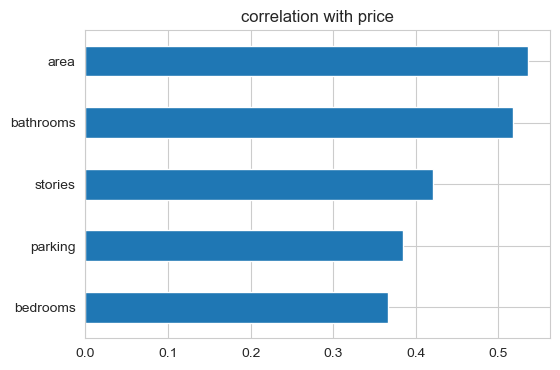

In [ ]:
num = df.select_dtypes('number')
corr = num.corr()['price'].drop('price').sort_values()
corr.plot.barh(figsize=(6, 4), title='correlation with price')
plt.show()

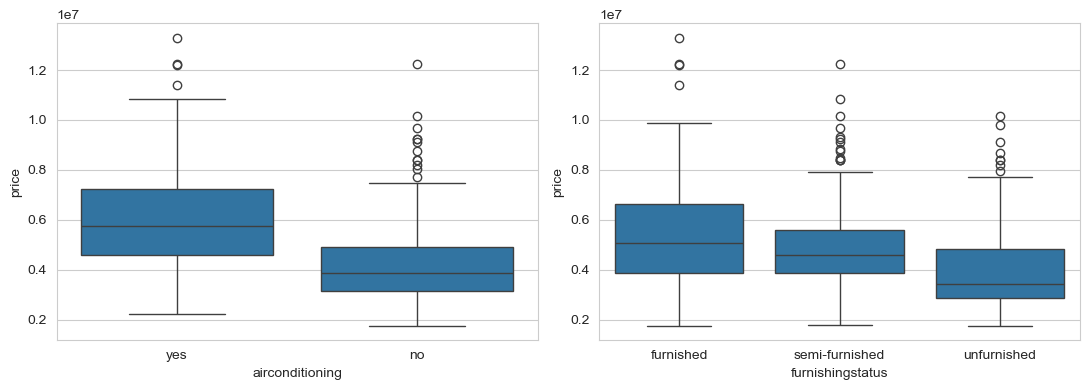

In [ ]:
# categorical breakdowns
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=df, x='airconditioning', y='price', ax=ax[0])
sns.boxplot(data=df, x='furnishingstatus', y='price', ax=ax[1])
plt.tight_layout()
plt.show()

## Cleaning the data


In [ ]:
print('missing:', df.isna().sum().sum())
print('duplicates:', df.duplicated().sum())

hi = df['area'].quantile(0.99)
df['area'] = df['area'].clip(upper=hi)

missing: 0
duplicates: 0


## Feature engineering


In [ ]:
df['area_per_bed'] = df['area'] / df['bedrooms']
df['bath_per_bed'] = df['bathrooms'] / df['bedrooms']
df['total_rooms'] = df['bedrooms'] + df['bathrooms']

amen = ['airconditioning', 'basement', 'hotwaterheating', 'guestroom']
df['amenities'] = (df[amen] == 'yes').sum(axis=1)

In [ ]:
binary = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary:
    df[col] = (df[col] == 'yes').astype(int)

df['furnishingstatus'] = df['furnishingstatus'].map({'unfurnished': 0, 'semi-furnished': 1, 'furnished': 2})

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,area_per_bed,bath_per_bed,total_rooms,amenities
0,13300000,7420.0,4,2,3,1,0,0,0,1,2,1,2,1855.0,0.500000,6,1
1,12250000,8960.0,4,4,4,1,0,0,0,1,3,0,2,2240.0,1.000000,8,1
2,12250000,9960.0,3,2,2,1,0,1,0,0,2,1,1,3320.0,0.666667,5,1
3,12215000,7500.0,4,2,2,1,0,1,0,1,3,1,2,1875.0,0.500000,6,2
4,11410000,7420.0,4,1,2,1,1,1,0,1,2,0,2,1855.0,0.250000,5,3


## Modeling

Linear Regression as baseline, then two tree models.

In [ ]:
X = df.drop(columns='price')
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((436, 16), (109, 16))

In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=300, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=300, random_state=42, verbose=-1),
}

res = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    res[name] = {'RMSE': rmse, 'R2': r2}

results = pd.DataFrame(res).T
results

,RMSE,R2
Linear Regression,1.329392e+06,0.650360
Random Forest,1.423428e+06,0.599146
LightGBM,1.364320e+06,0.631745


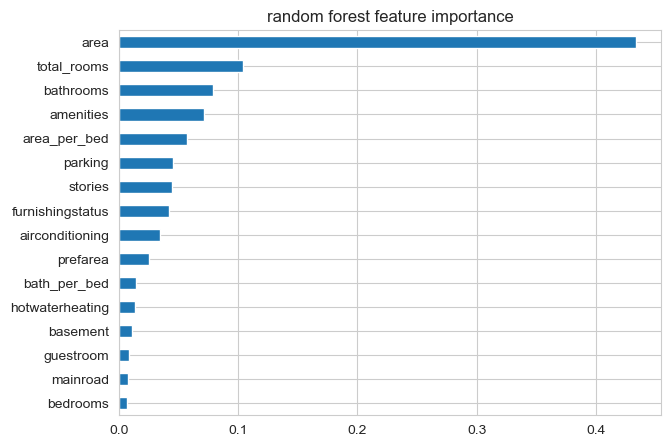

In [ ]:
# feature importance from the random forest
rf = models['Random Forest']
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
imp.plot.barh(figsize=(7, 5), title='random forest feature importance')
plt.show()

## Results

| model | RMSE | R2 |
|---|---|---|
| Linear Regression | 1.33M | 0.65 |
| LightGBM | 1.36M | 0.63 |
| Random Forest | 1.42M | 0.60 |

Linear Regression won, lowest RMSE at about 1.33M and R2 of 0.65. LightGBM was close behind, Random Forest a bit further off.